              year     quarter         sales
count   501.000000  501.000000  5.010000e+02
mean   2011.570858    2.502994  1.760585e+08
std       2.266599    1.120041  1.642055e+08
min    2008.000000    1.000000  6.274000e+06
25%    2010.000000    2.000000  6.148200e+07
50%    2012.000000    3.000000  1.385820e+08
75%    2014.000000    4.000000  2.241580e+08
max    2015.000000    4.000000  9.169100e+08
year       0
quarter    0
country    0
sales      0
dtype: int64
   year  quarter             country      sales
0  2008        1               Adams  231609000
1  2008        1            Arapahoe  550378000
2  2008        1  Boulder/Broomfield  176771000
3  2008        1              Denver  200103000
4  2008        1             Douglas   93259000
None


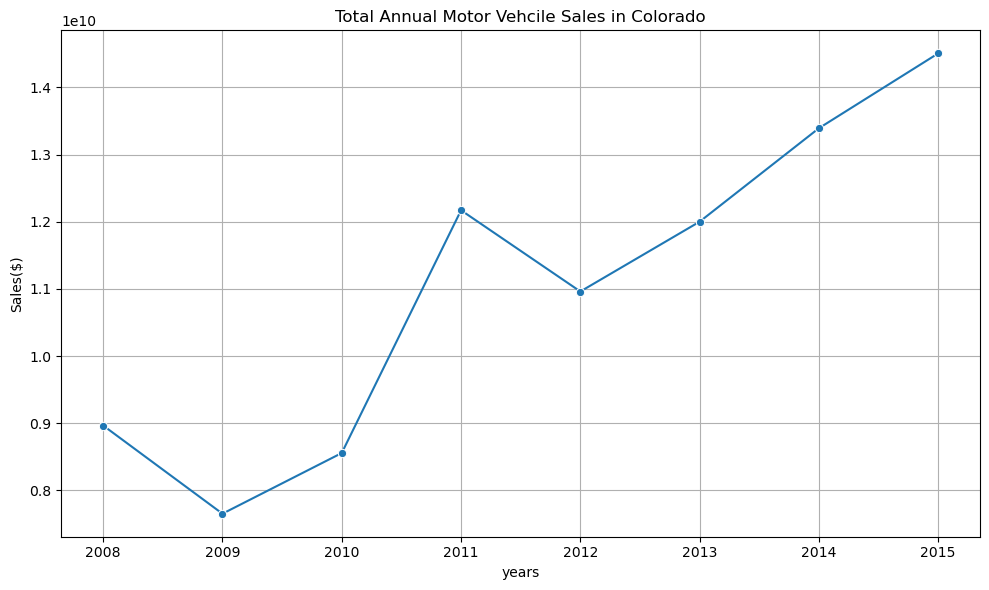

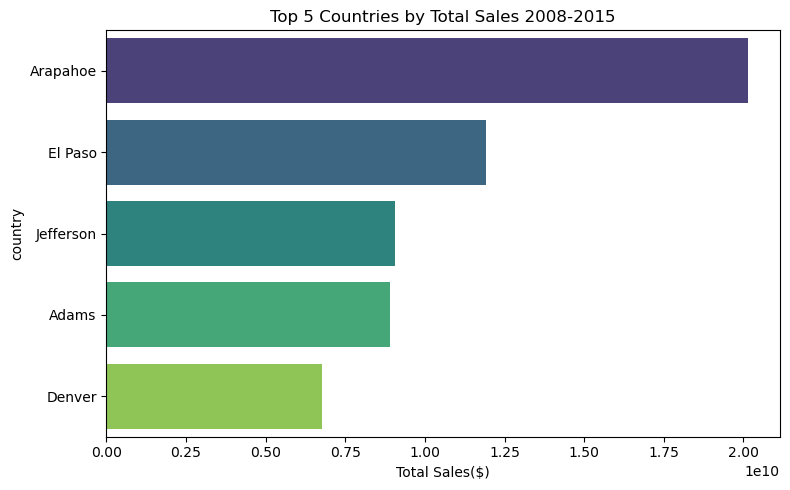

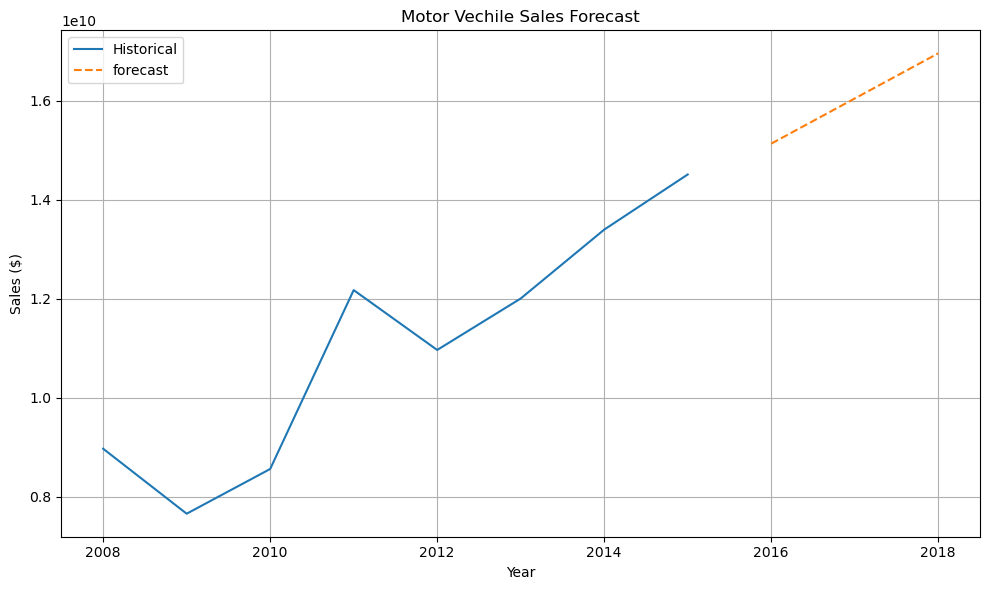

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('C:/Users/HP/Documents/DA_projects/colrado/colorado_motor_vehicle_sales.csv')
print(df.describe())
print(df.isnull().sum())
print(df.head())
print(df.dropna(inplace=True))
df['country']=df['country'].str.replace("Boulder/Broomfield", "Boulder")
annual_sales=df.groupby(['year','country'])['sales'].sum().reset_index()
total_annual_sales= annual_sales.groupby('year')['sales'].sum().reset_index()

# Visualize total annual sales trend
plt.figure(figsize=(10,6))
sns.lineplot(data=total_annual_sales, x='year', y='sales', marker='o')
plt.title('Total Annual Motor Vehcile Sales in Colorado')
plt.ylabel('Sales($)')
plt.xlabel('years')
plt.grid(True)
plt.tight_layout() 
plt.show()

#  Top 5 Countries by Total Sales
top_country= annual_sales.groupby('country')['sales'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8,5))
sns.barplot(x=top_country.values, y=top_country.index , palette='viridis')
plt.title('Top 5 Countries by Total Sales 2008-2015')
plt.xlabel('Total Sales($)')
plt.tight_layout()
plt.show()

# every year percentage change
total_annual_sales['pct_change']=total_annual_sales['sales'].pct_change()*100
country_volatility= annual_sales.groupby('country')['sales'].std().sort_values(ascending=False)

x=total_annual_sales['year'].values.reshape(-1,1)
y=total_annual_sales['sales'].values
model=LinearRegression().fit(x,y)

future_years=np.array([2016,2017,2018]).reshape(-1,1)
future_sales=model.predict(future_years)

plt.figure(figsize=(10,6))
sns.lineplot(x=total_annual_sales['year'],y=total_annual_sales['sales'],label='Historical')
sns.lineplot(x=future_years.flatten(), y=future_sales, label='forecast',linestyle="--")
plt.title('Motor Vechile Sales Forecast')
plt.xlabel('Year')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()